In [2]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
# Diagnostic: detect transect segments and plot each one on the ortho
# so we can assign correct transect labels.

import numpy as np
import matplotlib.pyplot as plt
import yaml
import rioxarray
import string
from PIL import Image

# ── utils_CIRN functions ───────────────────────────────────────────────────────
%run -i F:\crs\src\ShoreScan\runup\CODES\utils_CIRN.py

# ── Configuration ─────────────────────────────────────────────────────────────
CAL_DIR  = r"F:\crs\proj\marconi_imagery\calibration_parameters"
PIX_DIR  = r"F:\crs\proj\marconi_imagery\pixel_locations"

IO_C1 = CAL_DIR + r"\CACO03_c1_20240801_IO.yaml"
IO_C2 = CAL_DIR + r"\CACO03_c2_20240801_IO.yaml"
EO_C1 = CAL_DIR + r"\CACO03_c1_20241023_EO.yaml"
EO_C2 = CAL_DIR + r"\CACO03_c2_20241023_EO.yaml"

C1_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c1\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c1.snap.jpg"
C2_IMG = r"F:\crs\proj\marconi_imagery\caco-03\c2\2024\353_Dec.18\1734543000.Wed.Dec.18_17_30_00.GMT.2024.CACO03.c2.snap.jpg"
C1_PIX = PIX_DIR + r"\c1_timestack.pix"
C2_PIX = PIX_DIR + r"\c2_timestack.pix"

GRID_RES     = 0.2
CAM_X        = 420088.0
CAM_Y        = 4638320.0
x_min, x_max = CAM_X - 25.0, CAM_X + 125.0
y_min, y_max = CAM_Y - 10.0, CAM_Y + 240.0
Z_PLANE_PLOT = 0.0
GAP_FACTOR   = 10.0

# ── Load calibrations ─────────────────────────────────────────────────────────
def load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)

io1, io2 = load_yaml(IO_C1), load_yaml(IO_C2)
eo1, eo2 = load_yaml(EO_C1), load_yaml(EO_C2)

# ── Rectification grid ────────────────────────────────────────────────────────
xs = np.arange(x_min, x_max, GRID_RES)
ys = np.arange(y_min, y_max, GRID_RES)
Xg, Yg = np.meshgrid(xs, ys)
Zg      = np.full_like(Xg, Z_PLANE_PLOT)
xyz_grid = np.column_stack((Xg.ravel(), Yg.ravel(), Zg.ravel()))

def project_grid(xyz, io, eo):
    UVd, flag = xyz_to_dist_uv(io, eo, xyz)
    Ud = UVd[0].reshape(Xg.shape)
    Vd = UVd[1].reshape(Xg.shape)
    flag = flag.reshape(Xg.shape)
    valid = (flag == 1) & (Ud >= 0) & (Ud < io['NU']) & (Vd >= 0) & (Vd < io['NV'])
    Ud[~valid] = np.nan
    Vd[~valid] = np.nan
    return Ud, Vd

Ud1, Vd1 = project_grid(xyz_grid, io1, eo1)
Ud2, Vd2 = project_grid(xyz_grid, io2, eo2)

def sample_image(img_path, Ud, Vd):
    img = np.array(Image.open(img_path))
    h, w = img.shape[:2]
    Ir = np.zeros((*Ud.shape, 3), dtype=np.uint8)
    valid = ~np.isnan(Ud) & ~np.isnan(Vd)
    ui = np.where(valid, Ud, 0).astype(int).clip(0, w - 1)
    vi = np.where(valid, Vd, 0).astype(int).clip(0, h - 1)
    Ir[valid] = img[vi[valid], ui[valid]]
    return Ir, valid

Ir1, valid1 = sample_image(C1_IMG, Ud1, Vd1)
Ir2, valid2 = sample_image(C2_IMG, Ud2, Vd2)
IrIndv   = np.stack([Ir1, Ir2], axis=-1).astype(float)
Ir_merged = camera_seam_blend(IrIndv)

# ── Transect detection ────────────────────────────────────────────────────────
def get_transect_ids(uv, gap_factor=GAP_FACTOR):
    dists = np.linalg.norm(np.diff(uv, axis=0), axis=1)
    threshold = np.median(dists) * gap_factor
    breaks = np.where(dists > threshold)[0] + 1
    ids = np.zeros(len(uv), dtype=int)
    for seg_id, start in enumerate(breaks):
        ids[start:] = seg_id + 1
    return ids

c1_uv      = np.loadtxt(C1_PIX)
c2_uv      = np.loadtxt(C2_PIX)
c1_ids     = get_transect_ids(c1_uv)   # raw 0-based
c2_ids     = get_transect_ids(c2_uv)   # raw 0-based

# ── Project each segment to world coords at Z_PLANE_PLOT ─────────────────────
# Build list of (camera, raw_tid, E, N)
segments = []
for cam, ids, uv, io, eo in [('C1', c1_ids, c1_uv, io1, eo1),
                               ('C2', c2_ids, c2_uv, io2, eo2)]:
    for raw_tid in np.unique(ids):
        mask = ids == raw_tid
        xyz  = dist_uv_to_xyz(io, eo, uv[mask, 0], uv[mask, 1], 'z', Z_PLANE_PLOT)
        segments.append((cam, raw_tid, xyz[:, 0], xyz[:, 1]))

print(f"Detected {len(segments)} segments total")
for cam, raw_tid, E, N in segments:
    print(f"  {cam} tid={raw_tid}: {len(E)} pts  "
          f"E=[{E.min():.1f}, {E.max():.1f}]  N=[{N.min():.1f}, {N.max():.1f}]")

Detected 11 segments total
  C1 tid=0: 336 pts  E=[420197.5, 420230.8]  N=[4638479.5, 4638481.1]
  C1 tid=1: 823 pts  E=[420149.6, 420229.4]  N=[4638414.0, 4638419.0]
  C1 tid=2: 1115 pts  E=[420123.0, 420231.8]  N=[4638377.2, 4638388.3]
  C1 tid=3: 1310 pts  E=[420105.8, 420235.6]  N=[4638353.7, 4638368.7]
  C1 tid=4: 1370 pts  E=[420101.2, 420238.0]  N=[4638342.6, 4638358.8]
  C1 tid=5: 1342 pts  E=[420105.7, 420240.6]  N=[4638332.7, 4638348.7]
  C1 tid=6: 1314 pts  E=[420109.7, 420243.9]  N=[4638322.7, 4638338.3]
  C2 tid=0: 927 pts  E=[420089.7, 420221.7]  N=[4638454.5, 4638493.2]
  C2 tid=1: 592 pts  E=[420089.7, 420163.6]  N=[4638401.4, 4638415.0]
  C2 tid=2: 391 pts  E=[420089.6, 420135.2]  N=[4638371.0, 4638376.6]
  C2 tid=3: 141 pts  E=[420102.3, 420118.4]  N=[4638352.5, 4638353.6]


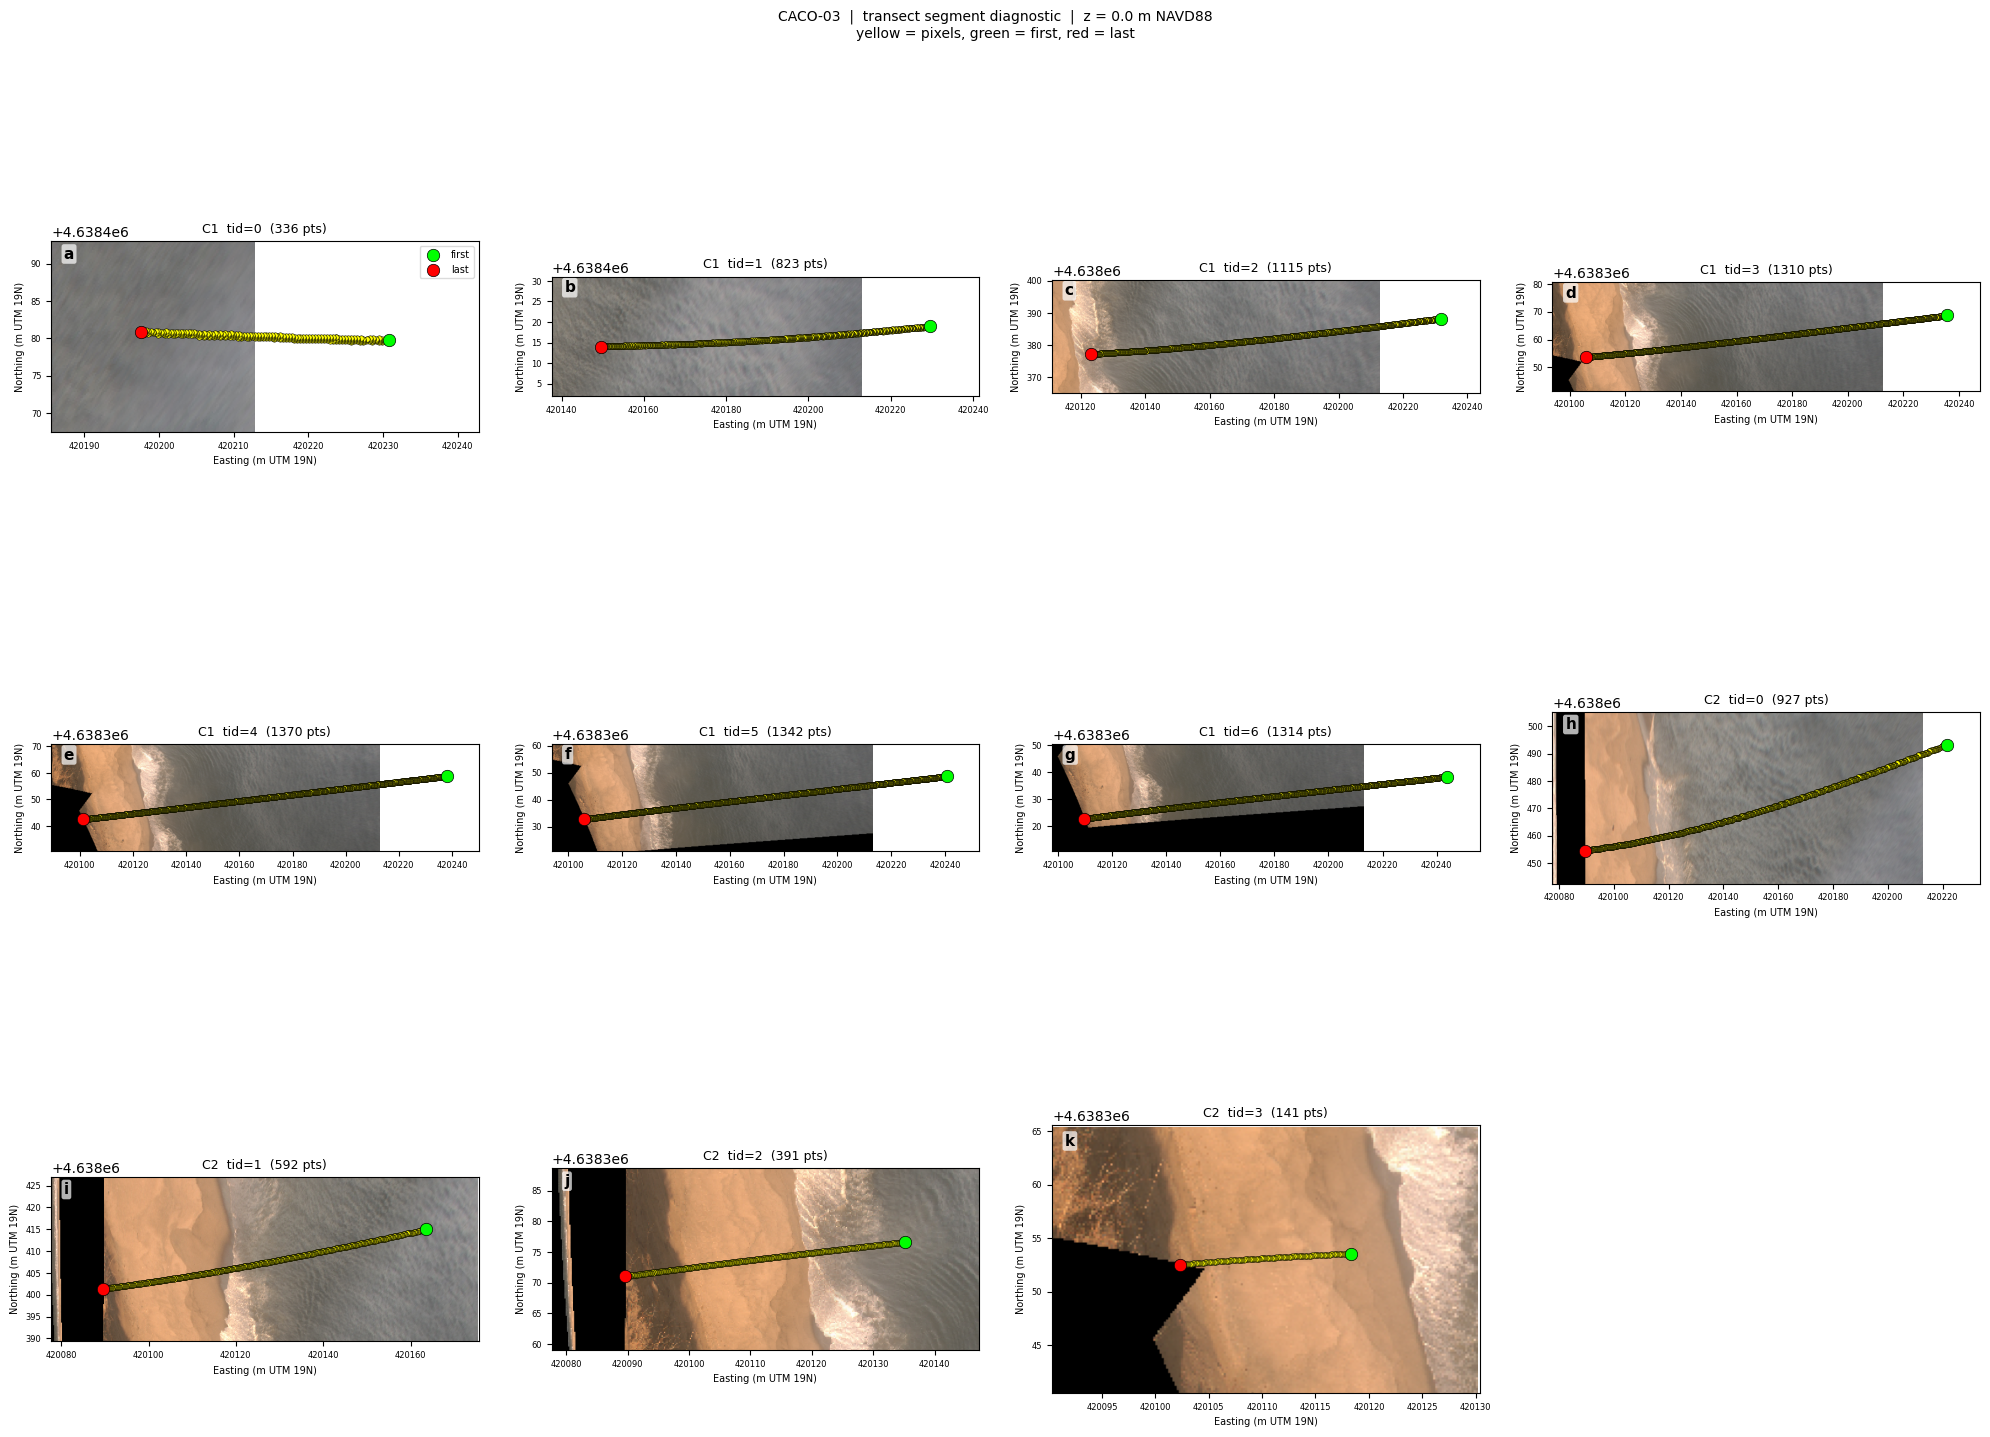

In [3]:
# csherwood@usgs.gov, 2026-06-16, generated with Claude Sonnet 4.6
# Plot each segment zoomed on the ortho — one panel per segment
# Green dot = first pixel, red dot = last pixel

ZOOM_PAD     = 12.0
panel_labels = string.ascii_lowercase
N_SEG        = len(segments)
ncols        = 4
nrows        = int(np.ceil(N_SEG / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.ravel()

for idx, (cam, raw_tid, E, N) in enumerate(segments):
    ax = axes[idx]

    x0 = E.min() - ZOOM_PAD;  x1 = E.max() + ZOOM_PAD
    y0 = N.min() - ZOOM_PAD;  y1 = N.max() + ZOOM_PAD

    ix0 = int(np.clip((x0 - xs[0]) / GRID_RES, 0, len(xs) - 1))
    ix1 = int(np.clip((x1 - xs[0]) / GRID_RES, 0, len(xs) - 1))
    iy0 = int(np.clip((y0 - ys[0]) / GRID_RES, 0, len(ys) - 1))
    iy1 = int(np.clip((y1 - ys[0]) / GRID_RES, 0, len(ys) - 1))
    crop = Ir_merged[iy0:iy1, ix0:ix1]
    ax.imshow(crop, origin='lower',
              extent=[xs[ix0], xs[ix1], ys[iy0], ys[iy1]],
              aspect='equal', zorder=0)

    ax.scatter(E, N, s=15, color='yellow', edgecolors='k',
               linewidths=0.4, zorder=5)
    ax.scatter(E[0],  N[0],  s=80, color='lime', edgecolors='k',
               linewidths=0.5, zorder=6, label='first')
    ax.scatter(E[-1], N[-1], s=80, color='red',  edgecolors='k',
               linewidths=0.5, zorder=6, label='last')

    ax.set_xlim(x0, x1)
    ax.set_ylim(y0, y1)
    ax.set_xlabel('Easting (m UTM 19N)', fontsize=7)
    ax.set_ylabel('Northing (m UTM 19N)', fontsize=7)
    ax.set_title(f'{cam}  tid={raw_tid}  ({len(E)} pts)', fontsize=9)
    ax.tick_params(labelsize=6)
    ax.text(0.03, 0.97, panel_labels[idx],
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.7, ec='none'))

axes[0].legend(fontsize=7, framealpha=0.7)
for ax in axes[N_SEG:]:
    ax.set_visible(False)

plt.suptitle(f'CACO-03  |  transect segment diagnostic  |  z = {Z_PLANE_PLOT} m NAVD88\n'
             'yellow = pixels, green = first, red = last',
             fontsize=10, y=1.01)
plt.tight_layout(h_pad=2.0, w_pad=1.5)
plt.savefig('transect_id_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

Transects are ordered north to south   
C1 tid=0: 336 pts  E=[420197.5, 420230.8]  N=[4638479.5, 4638481.1] - ignore  
C1 tid=1: 823 pts  E=[420149.6, 420229.4]  N=[4638414.0, 4638419.0] - ignore  
C1 tid=2: 1115 pts  E=[420123.0, 420231.8]  N=[4638377.2, 4638388.3] - ignore  
C1 tid=3: 1310 pts  E=[420105.8, 420235.6]  N=[4638353.7, 4638368.7] - T4S  
C1 tid=4: 1370 pts  E=[420101.2, 420238.0]  N=[4638342.6, 4638358.8] - T5  
C1 tid=5: 1342 pts  E=[420105.7, 420240.6]  N=[4638332.7, 4638348.7] - T6  
C1 tid=6: 1314 pts  E=[420109.7, 420243.9]  N=[4638322.7, 4638338.3] - T7  
C2 tid=0: 927 pts  E=[420089.7, 420221.7]  N=[4638454.5, 4638493.2] - T1  
C2 tid=1: 592 pts  E=[420089.7, 420163.6]  N=[4638401.4, 4638415.0] - T2  
C2 tid=2: 391 pts  E=[420089.6, 420135.2]  N=[4638371.0, 4638376.6] - T3  
C2 tid=3: 141 pts  E=[420102.3, 420118.4]  N=[4638352.5, 4638353.6] - T4N  